In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import Ridge, Lasso
from sympy.physics.quantum.density import entropy

from utils.utils import split_data_pd

pd.set_option('display.max_columns', None)  # показать все колонки
pd.set_option('display.max_rows', None)  # показать все строки (осторожно, если строк много)
pd.set_option('display.width', None)
%load_ext autoreload
%autoreload 2

In [2]:
data = pd.read_csv("src/data/train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# EDA

In [ ]:

data.info()
data.describe()

 1460 семплов и 80 колонок признаков. Судя по параметру std константных числовых фичей нет, масштаб сильно разный понадобится нормировка для линейный и метрических моделей. Есть значения где max сильно далеко от 75 перцентиля проверить на выбросы или аномалии, рассмотреть подробнее.

In [13]:
data.isna().sum()[data.isna().sum() > 0]


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

19 признаков с Nan. Большее кол-во нанов это PoolQC(почти 100% нанов), Alley, Fence, MiscFeature

In [14]:
corr_matrix = data.corr(numeric_only=True)
top = corr_matrix['SalePrice'].sort_values(ascending=False).head(15)
top

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

Наивысшая корелляция с таргетом это OverallQual GrLivArea GarageCars GarageArea. Проверить на выбросы топ 7 признаков с корелляцией.

In [ ]:
data.loc[:, top.index].corr(numeric_only=True)

Большая корелляция между признаками:
TotRmsAbvGrd: GrLivArea,
GarageCars: GarageArea,
1stFlrSF: TotalBsmtSF,
YearBuilt: GarageYrBlt



In [ ]:
data.SalePrice.hist()

Распределение таргетов имеет длинный хвост в право что логично для домена подобного типа, следует отлогарифимровать таргет.

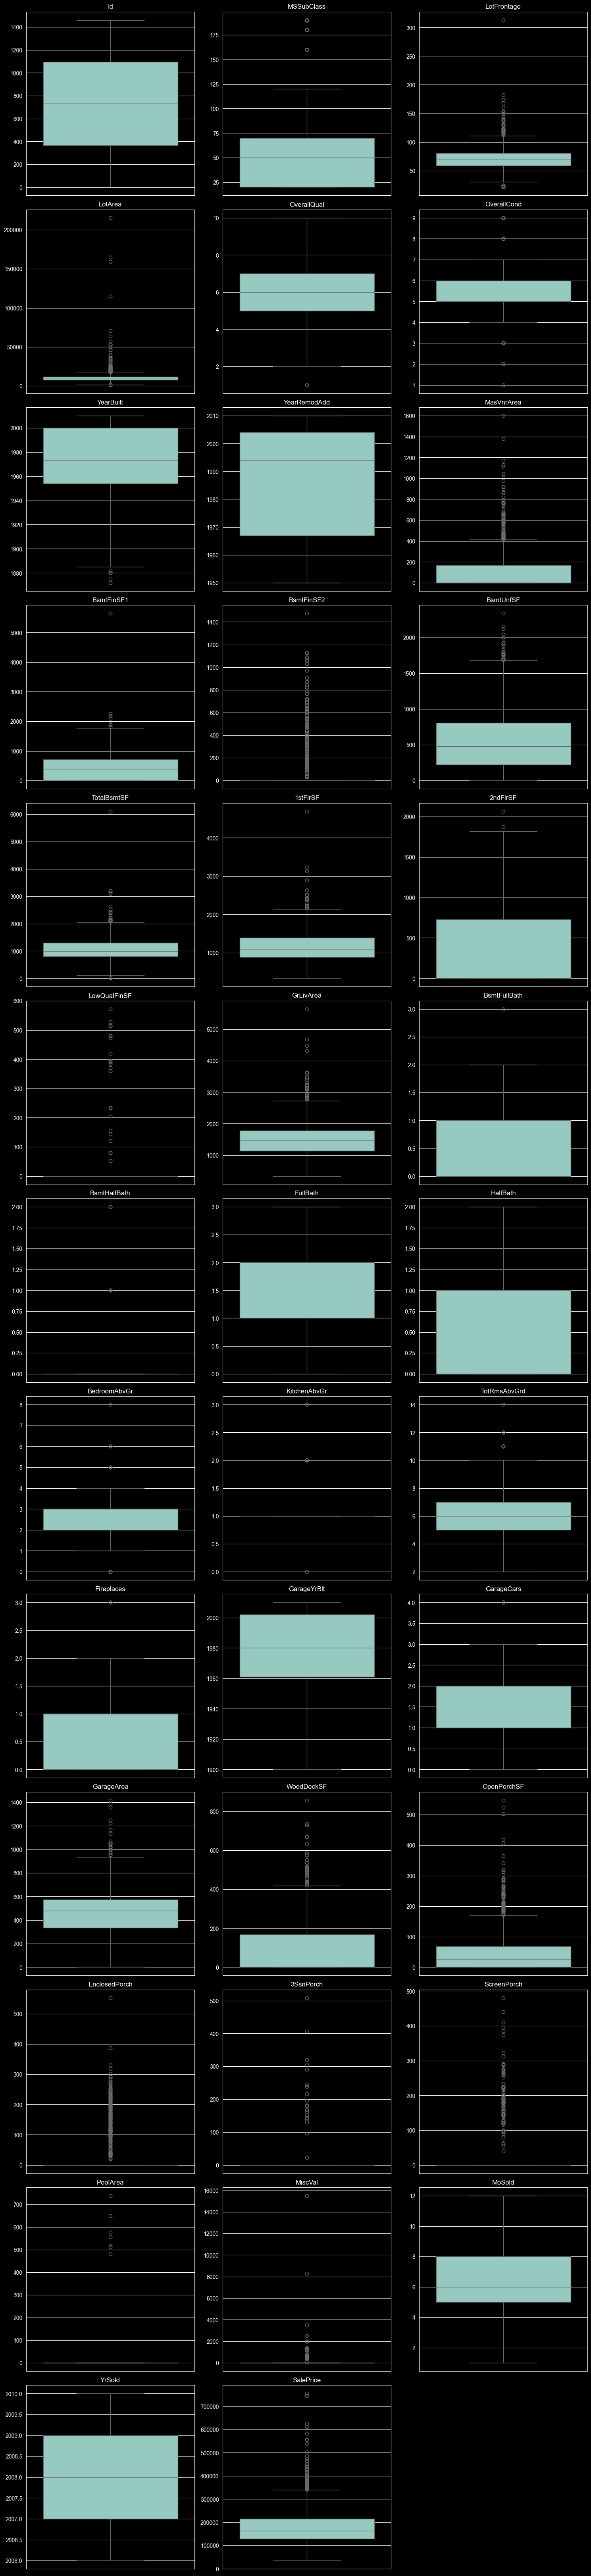

In [3]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns

n = len(numeric_cols)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Отсутствие боксов говорит о малом кол ве значений в клетках и возможных нулях, так же проверить на выбросы: LotFrontage
LotArea
MasVnrArea
BsmtFinSF1
BsmtFinSF2
TotalBsmtSf
1stFlrSF
GrLivArea

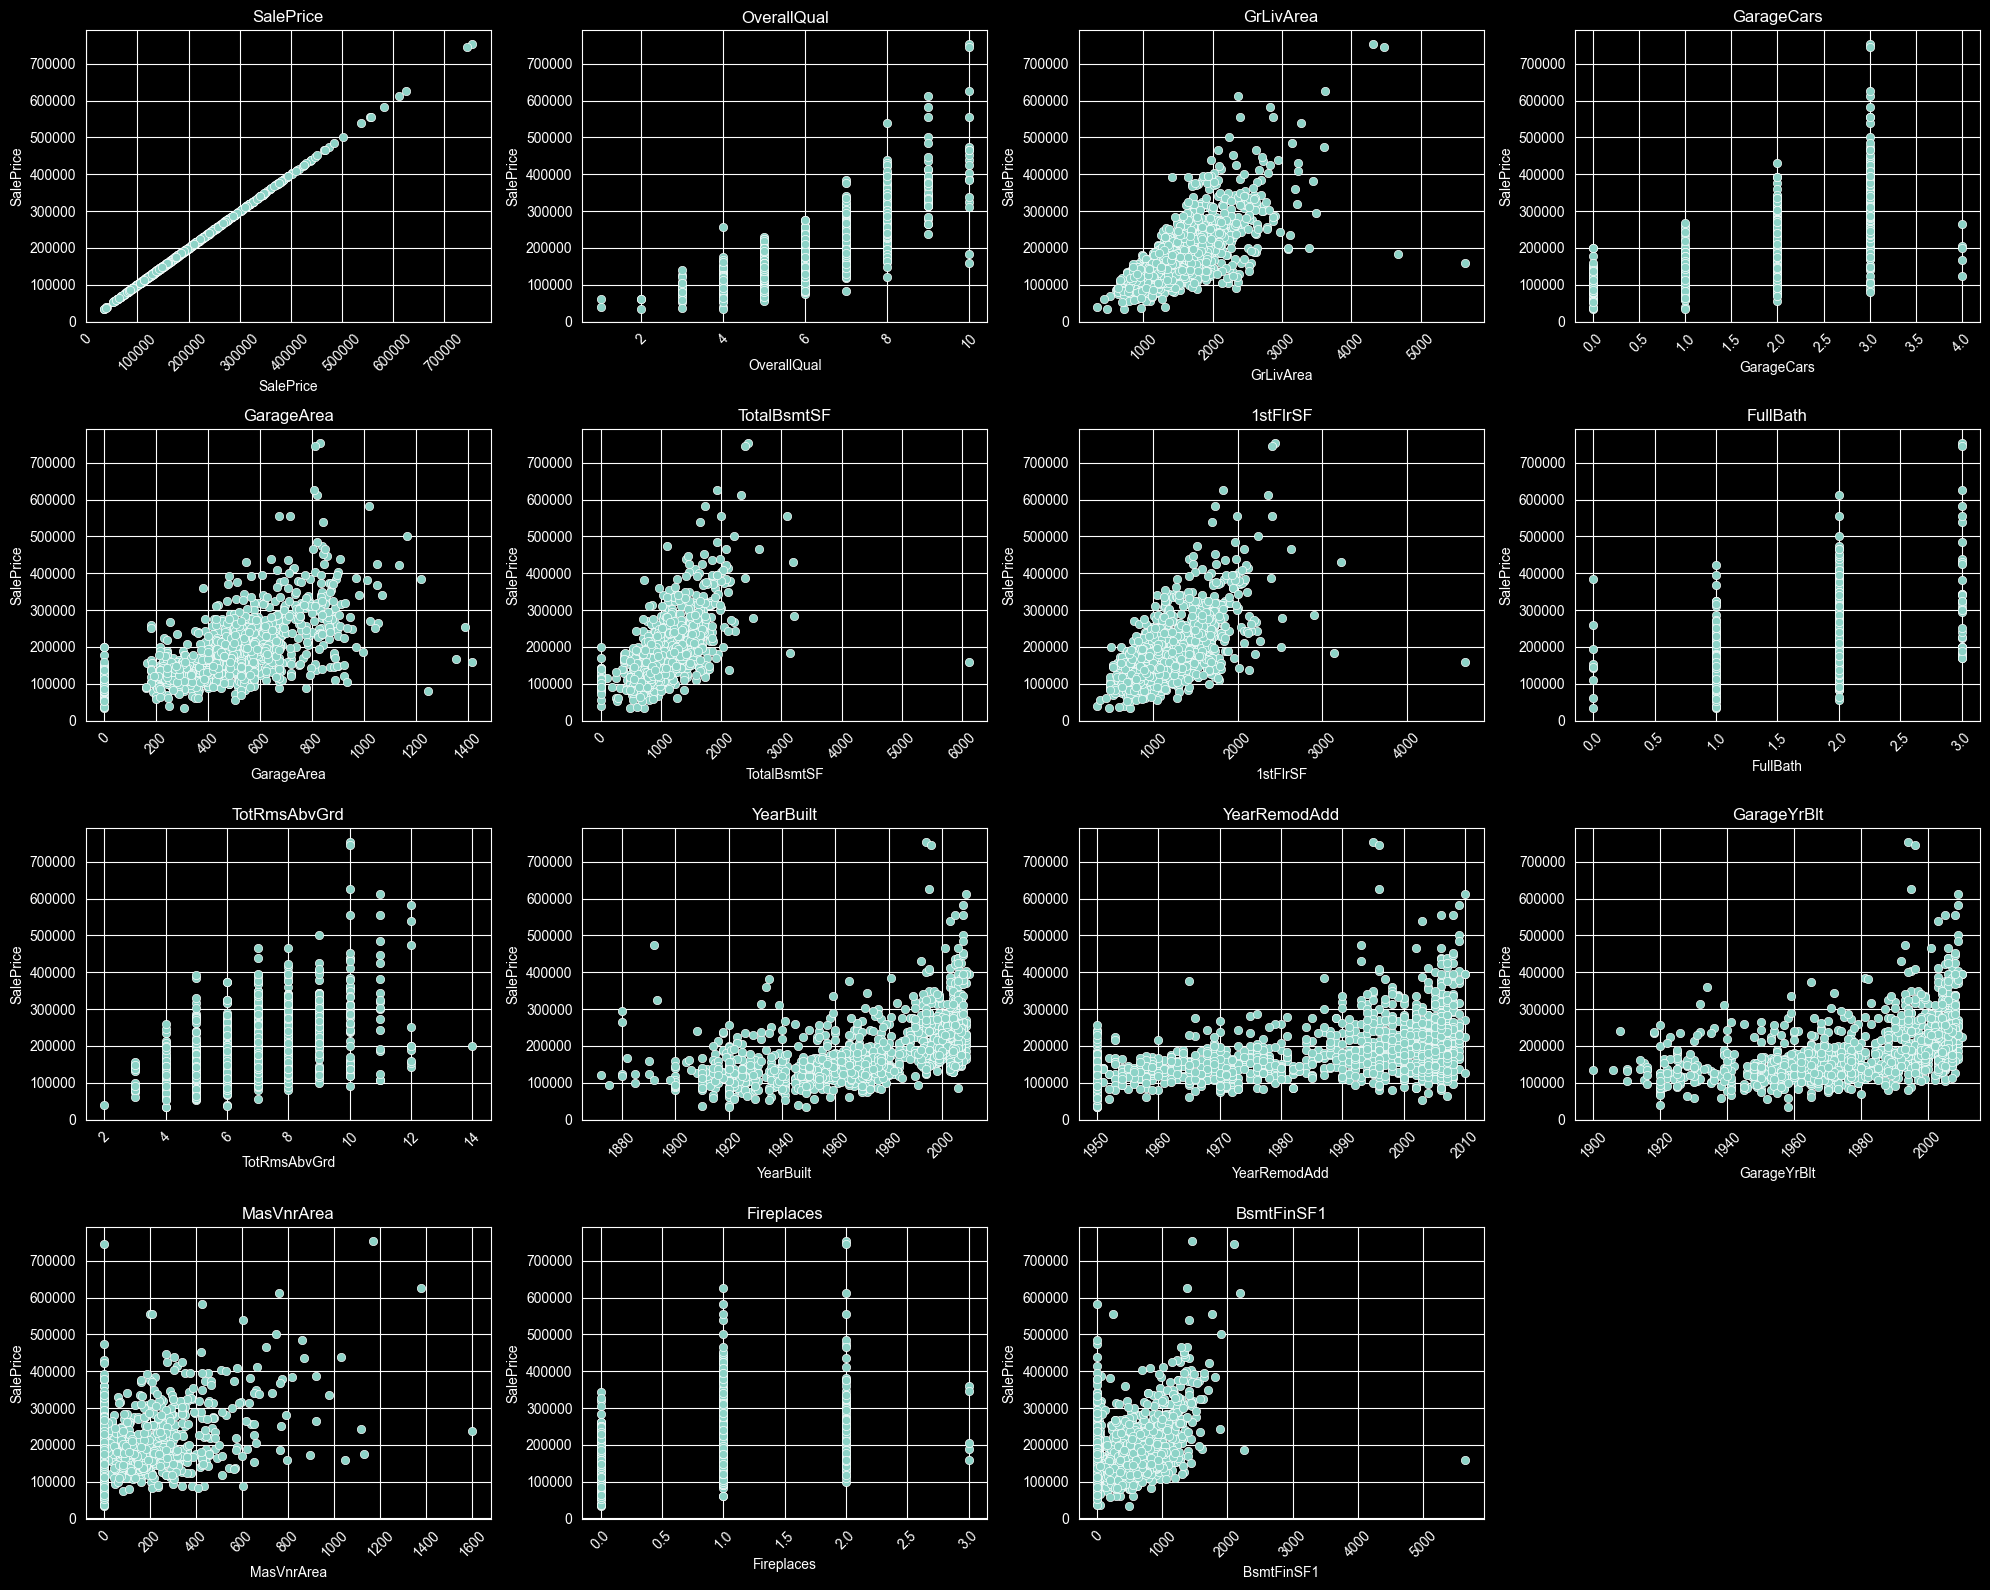

In [15]:
top_corr_cols = top.index

n_cols = 4
n_rows = -(-len(top_corr_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(top_corr_cols):
    sns.scatterplot(data=data, y="SalePrice", x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
outliers_glarea = data[(data['GrLivArea'] > 4000) & (data['SalePrice'] < 300000)]
print(outliers_glarea[['Id', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'MasVnrArea', 'SalePrice', 'LotFrontage']])

        Id  GrLivArea  GarageArea  TotalBsmtSF  MasVnrArea  SalePrice  \
523    524       4676         884         3138       762.0     184750   
1298  1299       5642        1418         6110       796.0     160000   

      LotFrontage  
523         130.0  
1298        313.0  


Проверка на выбросы top k нумерических фичей показала наличие двух аномалий которые детектятся в разных графиках ids: 524 1299

C:\Users\Дмитрий\AppData\Local\Temp\ipykernel_13800\4129390631.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = data.select_dtypes(include='object').columns.tolist()


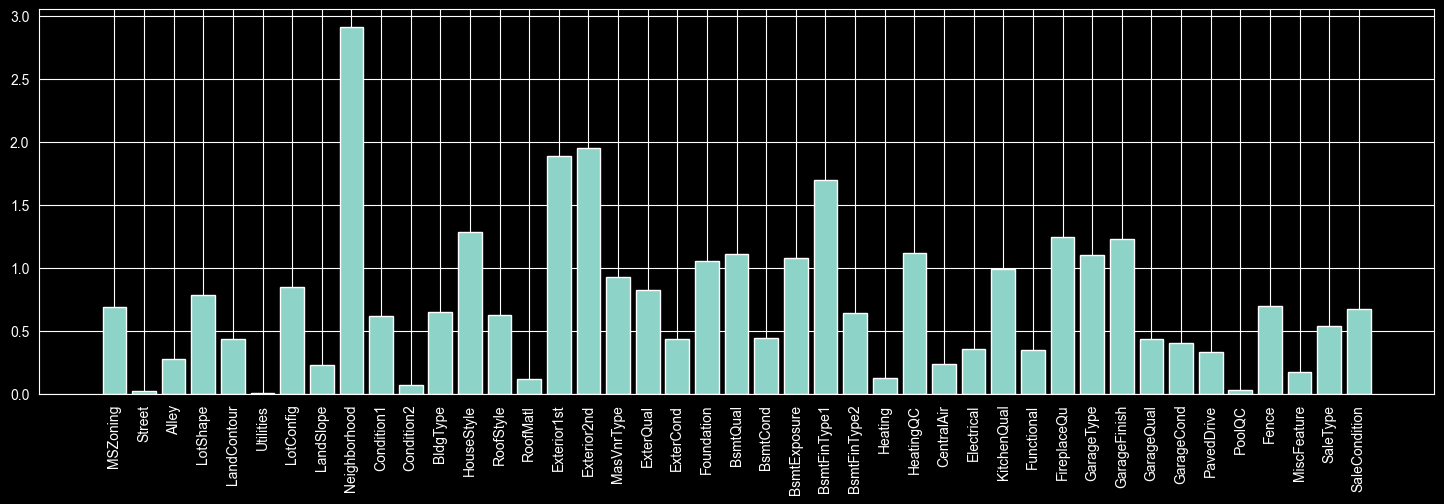

In [17]:
cat_features = data.select_dtypes(include='object').columns.tolist()
entropy_list = []

for f in cat_features:
    feature = data[f]
    frec = feature.shape[0]
    val_counts = feature.value_counts(dropna=False)
    p_vec = val_counts / frec
    entropy = (p_vec * np.log(p_vec) * -1).sum()
    entropy_list.append(entropy)

plt.figure(figsize=(18, 5))
plt.bar(cat_features, entropy_list)
plt.xticks(rotation=90)

plt.show()



Малая энтропия дает возможность понять дисбаланс классов внутри категории и то несет ли она какую то информативность, первично.

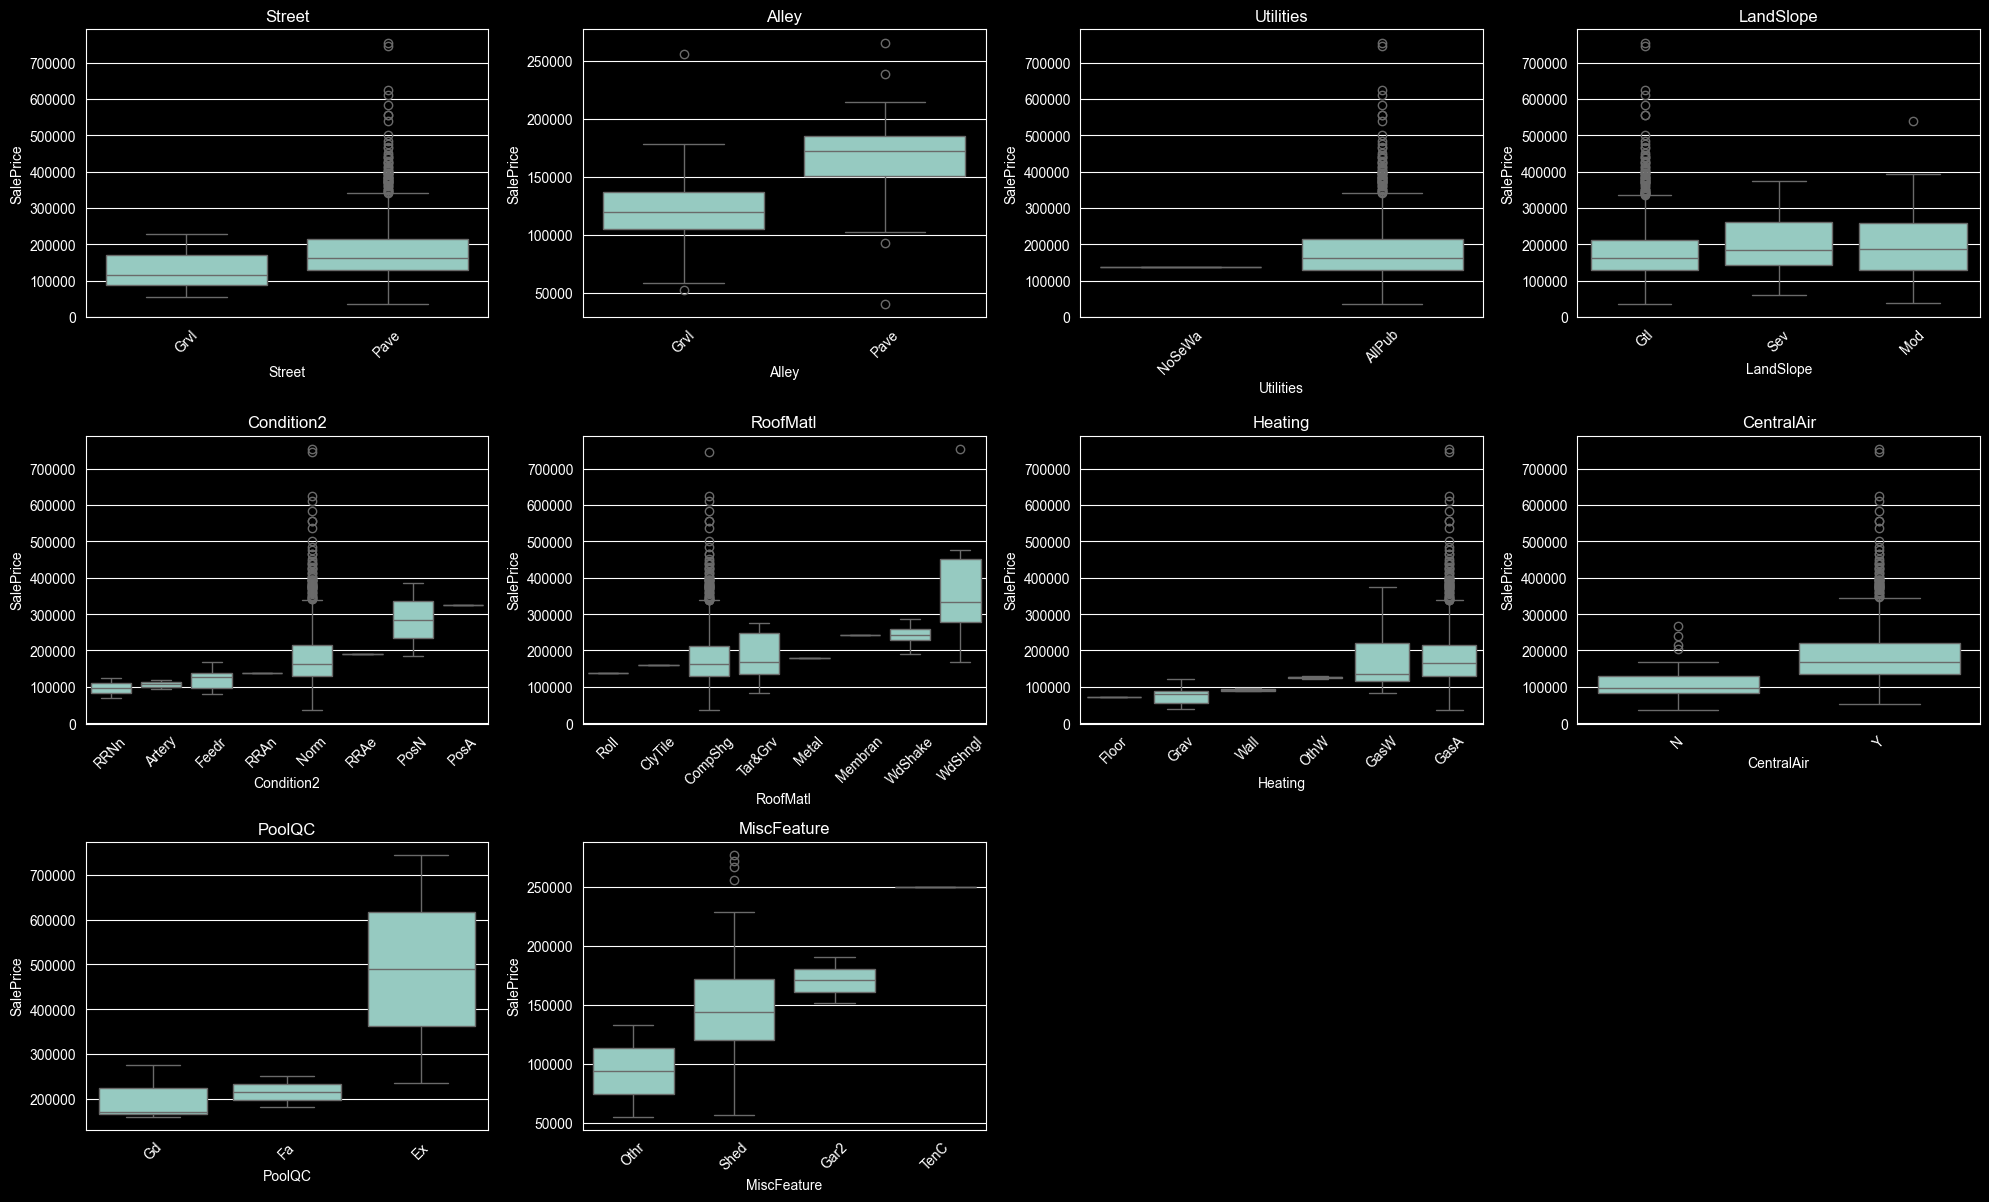

In [18]:
cf_high_e = []
cf_low_e = []

for i in range(len(cat_features)):
    if entropy_list[i] < 0.33:
        cf_low_e.append(cat_features[i])
    else:
        cf_high_e.append(cat_features[i])

n_cols = 4
n_rows = -(-len(cat_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cf_low_e):
    order = data.groupby(col)['SalePrice'].median().sort_values().index
    sns.boxplot(data=data, x=col, y='SalePrice', order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('cat_boxplots.png', dpi=100)
plt.show()

In [19]:

for f in cf_low_e:
    s = data.groupby(f)["SalePrice"].agg("count")
    print(s)

Street
Grvl       6
Pave    1454
Name: SalePrice, dtype: int64
Alley
Grvl    50
Pave    41
Name: SalePrice, dtype: int64
Utilities
AllPub    1459
NoSeWa       1
Name: SalePrice, dtype: int64
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: SalePrice, dtype: int64
Condition2
Artery       2
Feedr        6
Norm      1445
PosA         1
PosN         2
RRAe         1
RRAn         1
RRNn         2
Name: SalePrice, dtype: int64
RoofMatl
ClyTile       1
CompShg    1434
Membran       1
Metal         1
Roll          1
Tar&Grv      11
WdShake       5
WdShngl       6
Name: SalePrice, dtype: int64
Heating
Floor       1
GasA     1428
GasW       18
Grav        7
OthW        2
Wall        4
Name: SalePrice, dtype: int64
CentralAir
N      95
Y    1365
Name: SalePrice, dtype: int64
PoolQC
Ex    2
Fa    2
Gd    3
Name: SalePrice, dtype: int64
MiscFeature
Gar2     2
Othr     2
Shed    49
TenC     1
Name: SalePrice, dtype: int64


Street как кандидат на удаление тк почти константный, Alley смерджить в один, Utilites drop, в ландслоп сильный перевес в одну категорию поэтому стоит бинаризовать, PoolQC дроп,  misc_feature бинаризовать, Central_Air оставить, либо все колонки для биниризации возвести в признак Other. Condition2 биниризировать, roofmat биниризировать

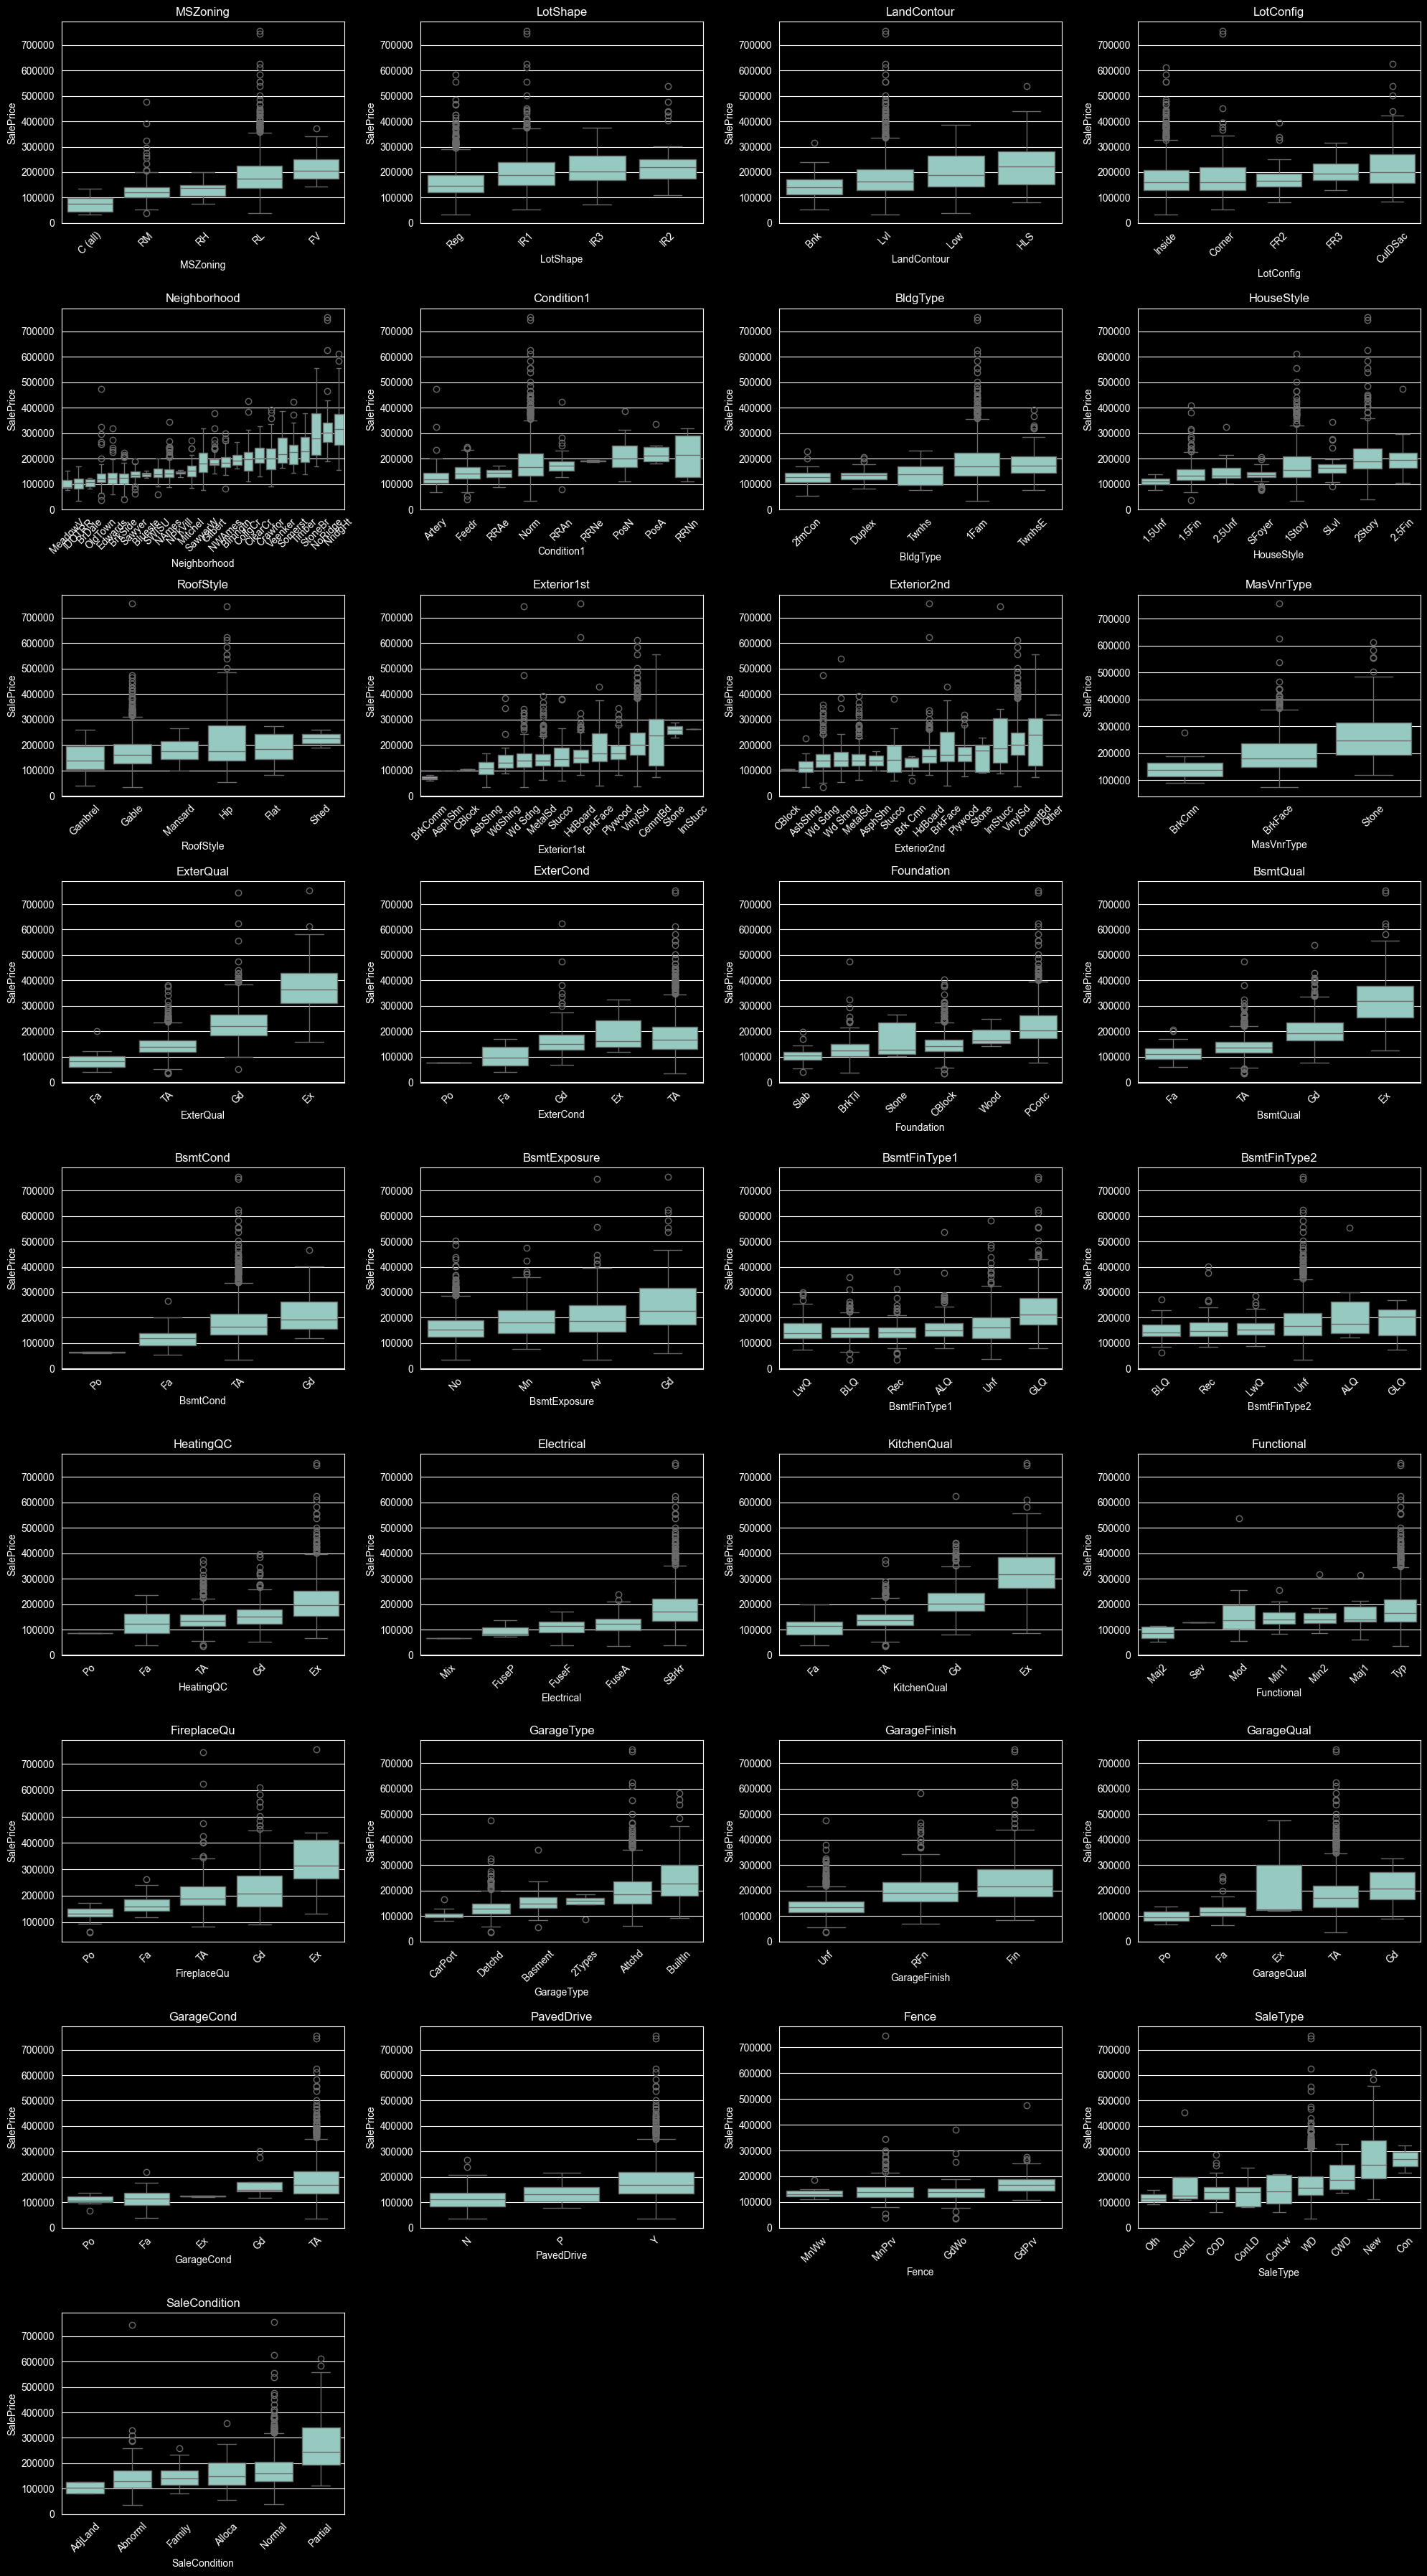

In [20]:


cat_features = cf_high_e

n_cols = 4
n_rows = -(-len(cat_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    order = data.groupby(col)['SalePrice'].median().sort_values().index
    sns.boxplot(data=data, x=col, y='SalePrice', order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('cat_boxplots.png', dpi=100)
plt.show()

In [21]:
for f in cf_high_e:
    s = data.groupby(f)["SalePrice"].agg("count")
    print(s)
    print("*"*50)

MSZoning
C (all)      10
FV           65
RH           16
RL         1151
RM          218
Name: SalePrice, dtype: int64
**************************************************
LotShape
IR1    484
IR2     41
IR3     10
Reg    925
Name: SalePrice, dtype: int64
**************************************************
LandContour
Bnk      63
HLS      50
Low      36
Lvl    1311
Name: SalePrice, dtype: int64
**************************************************
LotConfig
Corner      263
CulDSac      94
FR2          47
FR3           4
Inside     1052
Name: SalePrice, dtype: int64
**************************************************
Neighborhood
Blmngtn     17
Blueste      2
BrDale      16
BrkSide     58
ClearCr     28
CollgCr    150
Crawfor     51
Edwards    100
Gilbert     79
IDOTRR      37
MeadowV     17
Mitchel     49
NAmes      225
NPkVill      9
NWAmes      73
NoRidge     41
NridgHt     77
OldTown    113
SWISU       25
Sawyer      74
SawyerW     59
Somerst     86
StoneBr     25
Timber      38
Veenker    

Для признаков с высокой энтропией кандидаты это: GarageCond(бинаризация)  pavedDrive(бинаризация) BstmFinType2(бинаризация) MSZoning(бинаризация) LotShape(бинаризация + nulls cat)
Районы - onehot для безлайн,- Target encoding далее. Наличие нанов если есть значит расширяем категорию